# PL03 — Verificação do P1-D1 e Transfer Learning

**Objetivo:** validar a divisão sem fugas, comparar a CNN baseline da aula 2 com EfficientNetB0 como extrator de características e com fine-tuning, e avaliar o modelo escolhido no teste apenas no final.



In [2]:
# Ambiente e reprodutibilidade
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from pathlib import Path
from zipfile import ZipFile
from itertools import combinations
import time, json, platform
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

SEMENTE = 42
keras.utils.set_random_seed(SEMENTE)
print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("Backend:", keras.config.backend())
print("GPU:", tf.config.list_physical_devices("GPU"))


Python: 3.13.15
TensorFlow: 2.21.0
Keras: 3.13.2
Backend: tensorflow
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Preparar os ficheiros

No Colab, carregue o ZIP original, `splits.csv` gerado na aula 2 e `caracterizacao_classes.csv`. O CSV de divisão preserva a limpeza e a partição já realizadas; **não volte a sortear o split**.


In [3]:
from google.colab import files
carregados = files.upload()
print("Carregados:", list(carregados))

BASE = Path("/content")
zip_path = BASE / "archive (3).zip"
csv_path = BASE / "splits.csv"
destino = BASE / "bone_break_data"
assert zip_path.is_file(), "Carregue archive (3).zip"
assert csv_path.is_file(), "Carregue splits.csv"
if not destino.exists():
    with ZipFile(zip_path) as zf:
        zf.extractall(destino)
pasta_imagens = destino / "Bone Break Classification" / "Bone Break Classification"
df = pd.read_csv(csv_path)
assert {"caminho_relativo", "classe", "conjunto"}.issubset(df.columns)
classes = sorted(df.classe.unique())
indice_classe = {c:i for i,c in enumerate(classes)}
print("Raiz encontrada:", pasta_imagens.is_dir())
print("Registos:", len(df), "| Classes:", len(classes))
print(df.conjunto.value_counts())


Saving archive (3).zip to archive (3).zip
Carregados: ['archive (3).zip']
Raiz encontrada: True
Registos: 1045 | Classes: 10
conjunto
treino       731
validacao    157
teste        157
Name: count, dtype: int64


## 2. Verificar dados, classes e ausência de fugas

A divisão tem de conter treino, validação e teste, sem caminhos repetidos, ficheiros em falta, rótulos divergentes ou hashes iguais entre conjuntos. A matriz mostra as contagens por classe e conjunto.


In [4]:
assert set(df.conjunto) == {"treino", "validacao", "teste"}
assert not df.caminho_relativo.duplicated().any()
faltantes = [p for p in df.caminho_relativo if not (pasta_imagens/p).is_file()]
erros_rotulo = [r.caminho_relativo for r in df.itertuples() if (pasta_imagens/r.caminho_relativo).parent.parent.name != r.classe]
assert not faltantes, faltantes[:5]
assert not erros_rotulo, erros_rotulo[:5]
contagens = pd.crosstab(df.classe, df.conjunto).reindex(columns=["treino","validacao","teste"], fill_value=0)
display(contagens)
print("Ficheiros em falta:",len(faltantes),"| Rótulos divergentes:",len(erros_rotulo))

import hashlib
def sha256_file(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for b in iter(lambda:f.read(1<<20),b""): h.update(b)
    return h.hexdigest()
df["sha256"]=[sha256_file(pasta_imagens/p) for p in df.caminho_relativo]
hashes={s:set(df.loc[df.conjunto==s,"sha256"]) for s in ["treino","validacao","teste"]}
for a,b in combinations(hashes,2):
    n=len(hashes[a]&hashes[b]); print(f"Interseção SHA256 {a} × {b}: {n}"); assert n==0
print("Contagens totais:",df.conjunto.value_counts().to_dict())


conjunto,treino,validacao,teste
classe,,,
Avulsion fracture,84,18,18
Comminuted fracture,91,19,20
Fracture Dislocation,103,22,22
Greenstick fracture,82,18,17
Hairline Fracture,76,16,17
Impacted fracture,52,11,11
Longitudinal fracture,49,11,11
Oblique fracture,56,12,12
Pathological fracture,86,19,18


Ficheiros em falta: 0 | Rótulos divergentes: 0
Interseção SHA256 treino × validacao: 0
Interseção SHA256 treino × teste: 0
Interseção SHA256 validacao × teste: 0
Contagens totais: {'treino': 731, 'validacao': 157, 'teste': 157}


## 3. Carregar imagens

A baseline da aula 2 usa imagens 180×180 e rótulos one-hot. Os modelos EfficientNet usam 224×224 e rótulos inteiros, conforme a perda `sparse_categorical_crossentropy`. O conjunto de teste fica definido, mas não é consumido durante treino nem escolha de modelo.


In [5]:
BATCH=32
AUTOTUNE=tf.data.AUTOTUNE
def criar_dataset(nome, tamanho, one_hot=False, shuffle=False):
    dados=df[df.conjunto==nome]
    caminhos=[str(pasta_imagens/p) for p in dados.caminho_relativo]
    ys=dados.classe.map(indice_classe).to_numpy(dtype="int32")
    ds=tf.data.Dataset.from_tensor_slices((caminhos,ys))
    def carregar(p,y):
        im=tf.io.decode_image(tf.io.read_file(p),channels=3,expand_animations=False)
        im=tf.image.resize(im,tamanho)
        if one_hot: y=tf.one_hot(y,len(classes))
        return im,y
    ds=ds.map(carregar,num_parallel_calls=AUTOTUNE)
    if shuffle: ds=ds.shuffle(len(dados),seed=SEMENTE,reshuffle_each_iteration=True)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train180=criar_dataset("treino",(180,180),one_hot=True,shuffle=True)
val180=criar_dataset("validacao",(180,180),one_hot=True)
train224=criar_dataset("treino",(224,224),shuffle=True)
val224=criar_dataset("validacao",(224,224))
test224=criar_dataset("teste",(224,224))
xb,yb=next(iter(train180)); xe,ye=next(iter(train224))
print("Baseline:",xb.shape,yb.shape,"pixels",float(tf.reduce_min(xb)),float(tf.reduce_max(xb)))
print("EfficientNet:",xe.shape,ye.shape,"pixels",float(tf.reduce_min(xe)),float(tf.reduce_max(xe)))


Baseline: (32, 180, 180, 3) (32, 10) pixels 0.0 255.0
EfficientNet: (32, 224, 224, 3) (32,) pixels 0.0 255.0


## 4. CNN baseline da aula 2

Reproduzimos a arquitetura baseline entregue na aula 2 e registamos a melhor época pela menor `val_loss`. Este modelo fornece a comparação de referência do PL03.


In [6]:
keras.utils.set_random_seed(SEMENTE)
modelo_baseline=keras.Sequential([
    keras.Input(shape=(180,180,3)), keras.layers.Rescaling(1./255),
    keras.layers.Conv2D(32,3,activation="relu"),keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64,3,activation="relu"),keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(128,3,activation="relu"),keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(256,3,activation="relu"),keras.layers.MaxPooling2D(2),
    keras.layers.GlobalAveragePooling2D(),keras.layers.Dense(len(classes),activation="softmax")
],name="cnn_baseline_pl02")
modelo_baseline.compile(optimizer=keras.optimizers.Adam(1e-3),loss="categorical_crossentropy",metrics=["accuracy"])
modelo_baseline.summary()
resultados_dir=Path("/content/resultados_pl03"); resultados_dir.mkdir(exist_ok=True)
cb_baseline=[keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True),
 keras.callbacks.ModelCheckpoint(str(resultados_dir/"baseline_melhor.keras"),monitor="val_loss",save_best_only=True),
 keras.callbacks.CSVLogger(str(resultados_dir/"baseline.csv"))]
t0=time.perf_counter()
h_baseline=modelo_baseline.fit(train180,validation_data=val180,epochs=30,callbacks=cb_baseline)
t_baseline=time.perf_counter()-t0


Model: "cnn_baseline_pl02"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,986 (1.49 MB)

 Trainable params: 390,986 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 726ms/step - accuracy: 0.1327 - loss: 2.2906 - val_accuracy: 0.1210 - val_loss: 2.2793
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.1190 - loss: 2.2703 - val_accuracy: 0.1338 - val_loss: 2.2646
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.1532 - loss: 2.2520 - val_accuracy: 0.1720 - val_loss: 2.2333
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1601 - loss: 2.2362 - val_accuracy: 0.1529 - val_loss: 2.2507
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.1683 - loss: 2.2330 - val_accuracy: 0.1592 - val_loss: 2.2391
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.1642 - loss: 2.2134 - val_accuracy: 0.1783 - val_loss: 2.2085
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.1669 - loss: 2.2078 - val_accuracy: 0.1720 - val_loss: 2.2189
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.1737 - loss: 2.1969 - val_accuracy: 0.1847 -

## 5. EfficientNetB0 — extração de características

A EfficientNetB0 recebe píxeis entre 0 e 255; por isso não aplicamos `Rescaling`. O aumento aleatório fica dentro do modelo e atua apenas durante o treino. A base fica congelada.


In [7]:
augment=keras.Sequential([keras.layers.RandomFlip("horizontal"),keras.layers.RandomRotation(0.1),keras.layers.RandomZoom(0.2)],name="augmentacao")
base=keras.applications.EfficientNetB0(include_top=False,weights="imagenet",input_shape=(224,224,3))
base.trainable=False
inp=keras.Input((224,224,3))
x=augment(inp)
x=base(x,training=False)
x=keras.layers.GlobalAveragePooling2D()(x)
x=keras.layers.Dropout(0.3)(x)
out=keras.layers.Dense(len(classes),activation="softmax")(x)
modelo_fe=keras.Model(inp,out,name="efficientnet_feature_extractor")
modelo_fe.summary()
print("Parâmetros totais:",modelo_fe.count_params(),"| Treináveis:",sum(int(np.prod(v.shape)) for v in modelo_fe.trainable_weights))
modelo_fe.compile(optimizer=keras.optimizers.Adam(1e-3),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
cb_fe=[keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True),
 keras.callbacks.ModelCheckpoint(str(resultados_dir/"feature_extractor_melhor.keras"),monitor="val_loss",save_best_only=True),
 keras.callbacks.TensorBoard(log_dir=str(resultados_dir/"logs/feature_extractor")),
 keras.callbacks.CSVLogger(str(resultados_dir/"feature_extractor.csv"))]
t0=time.perf_counter()
h_fe=modelo_fe.fit(train224,validation_data=val224,epochs=30,callbacks=cb_fe)
t_fe=time.perf_counter()-t0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnet_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentacao (Sequential)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Parâmetros totais: 4062381 | Treináveis: 12810
Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 335ms/step - accuracy: 0.1190 - loss: 2.3873 - val_accuracy: 0.1401 - val_loss: 2.2833
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.2107 - loss: 2.1852 - val_accuracy: 0.1783 - val_loss: 2.1884
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step - accuracy: 0.2681 - loss: 2.0570 - val_accuracy: 0.2166 - val_loss: 2.1446
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.3119 - loss: 1.9880 - val_accuracy: 0.2484 - val_loss: 2.1161
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.3584 - loss: 1.9053 - val_accuracy: 0.2229 - val_loss: 2.0908
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.3776 - loss: 1.8358 - val_accuracy: 0.2357 - val_loss: 2.0689
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.3967 - loss: 1.8233 - val_accuracy: 0.2548 - val_loss: 2.0572
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - ac

## 6. Fine-tuning

Descongelamos as últimas 20 camadas da base, mantendo BatchNormalization congelada, e continuamos com learning rate 100 vezes menor (`1e-5`). O argumento `training=False` mantém as estatísticas de BatchNormalization no modo inferência.


In [8]:
base.trainable=True
for camada in base.layers[:-20]: camada.trainable=False
for camada in base.layers[-20:]:
    if isinstance(camada,keras.layers.BatchNormalization): camada.trainable=False
print("Camadas treináveis na base:",sum(c.trainable for c in base.layers))
print("Parâmetros treináveis no modelo:",sum(int(np.prod(v.shape)) for v in modelo_fe.trainable_weights))
modelo_fe.compile(optimizer=keras.optimizers.Adam(1e-5),loss="sparse_categorical_crossentropy",metrics=["accuracy"])
cb_ft=[keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True),
 keras.callbacks.ModelCheckpoint(str(resultados_dir/"fine_tuning_melhor.keras"),monitor="val_loss",save_best_only=True),
 keras.callbacks.TensorBoard(log_dir=str(resultados_dir/"logs/fine_tuning")),
 keras.callbacks.CSVLogger(str(resultados_dir/"fine_tuning.csv"))]
t0=time.perf_counter()
h_ft=modelo_fe.fit(train224,validation_data=val224,epochs=20,callbacks=cb_ft)
t_ft=time.perf_counter()-t0


Camadas treináveis na base: 15
Parâmetros treináveis no modelo: 1355578
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 268ms/step - accuracy: 0.5677 - loss: 1.3772 - val_accuracy: 0.3885 - val_loss: 1.9205
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.5554 - loss: 1.3675 - val_accuracy: 0.3822 - val_loss: 1.9258
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.5376 - loss: 1.3681 - val_accuracy: 0.3885 - val_loss: 1.9291
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.5280 - loss: 1.3675 - val_accuracy: 0.3949 - val_loss: 1.9278
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.5663 - loss: 1.3338 - val_accuracy: 0.3885 - val_loss: 1.9320
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.5746 - loss: 1.2992 - val_accuracy: 0.3885 - val_loss: 1.9381


## 7. Curvas e comparação pela validação

A melhor época é escolhida pela menor `val_loss`. Reportamos também accuracy e F1 macro na validação. O F1 macro dá o mesmo peso a cada classe, útil porque as frequências diferem. Ainda não usamos o teste.


,Modelo,Parâmetros treináveis,Melhor época (val_loss),Menor val_loss,Accuracy validação,F1 macro validação,Tempo (min)
0,Baseline aula 2,390986,18,2.1754,0.2102,0.1410,1.2827
1,EfficientNetB0 — extrator,12810,25,1.9172,0.3822,0.3340,2.3137
2,EfficientNetB0 — fine-tuning,1355578,1,1.9205,0.3885,0.3399,0.5771


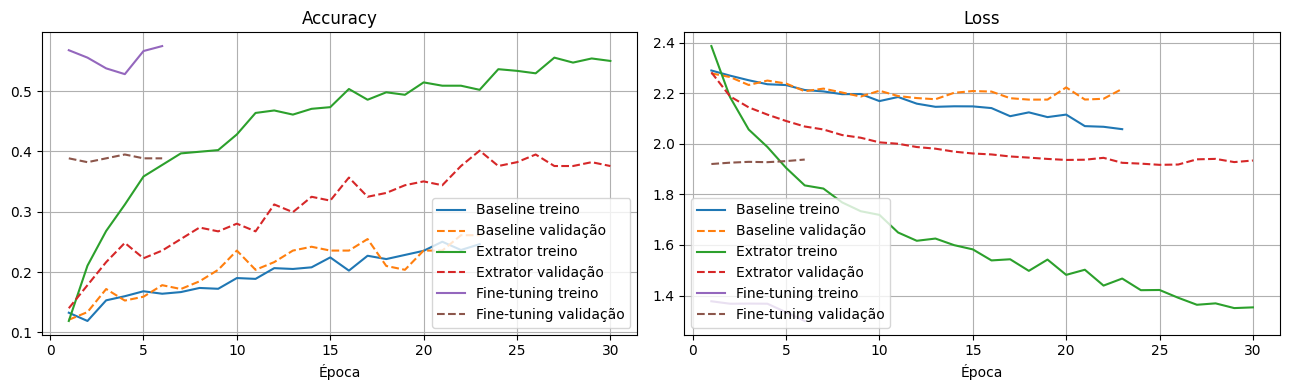

In [9]:
def melhor_epoca(hist): return int(np.argmin(hist.history["val_loss"]))
def metricas_validacao(modelo, ds, one_hot=False):
    yt=[]
    for _,y in ds: yt.extend(np.argmax(y.numpy(),axis=1) if one_hot else y.numpy().tolist())
    yp=np.argmax(modelo.predict(ds,verbose=0),axis=1)
    return accuracy_score(yt,yp),f1_score(yt,yp,average="macro",zero_division=0)

def resumo(nome,modelo,hist,ds,one_hot,tempo):
    i=melhor_epoca(hist); acc,f1=metricas_validacao(modelo,ds,one_hot)
    return {"Modelo":nome,"Parâmetros treináveis":sum(int(np.prod(v.shape)) for v in modelo.trainable_weights),"Melhor época (val_loss)":i+1,"Menor val_loss":hist.history["val_loss"][i],"Accuracy validação":acc,"F1 macro validação":f1,"Tempo (min)":tempo/60}

resumos=[resumo("Baseline aula 2",modelo_baseline,h_baseline,val180,True,t_baseline),resumo("EfficientNetB0 — extrator",keras.models.load_model(resultados_dir/"feature_extractor_melhor.keras"),h_fe,val224,False,t_fe),resumo("EfficientNetB0 — fine-tuning",keras.models.load_model(resultados_dir/"fine_tuning_melhor.keras"),h_ft,val224,False,t_ft)]
tabela_resultados=pd.DataFrame(resumos); display(tabela_resultados.round(4)); tabela_resultados.to_csv(resultados_dir/"comparacao_validacao.csv",index=False)

fig,axs=plt.subplots(1,2,figsize=(13,4))
for name,h in [("Baseline",h_baseline),("Extrator",h_fe),("Fine-tuning",h_ft)]:
    e=range(1,len(h.history["loss"])+1); axs[0].plot(e,h.history["accuracy"],label=name+" treino"); axs[0].plot(e,h.history["val_accuracy"],"--",label=name+" validação")
    axs[1].plot(e,h.history["loss"],label=name+" treino"); axs[1].plot(e,h.history["val_loss"],"--",label=name+" validação")
axs[0].set_title("Accuracy"); axs[1].set_title("Loss")
for ax in axs: ax.set_xlabel("Época"); ax.grid(True); ax.legend()
plt.tight_layout(); plt.savefig(resultados_dir/"curvas_comparacao.png",dpi=160); plt.show()


## 8. Escolher o modelo e avaliar no teste uma única vez

A seleção é feita exclusivamente pela validação: menor `val_loss` (com F1 macro e accuracy apresentados como contexto). A célula abaixo escolhe o checkpoint com menor `val_loss` de validação e então calcula as métricas no teste. Não altere o modelo com base nesse resultado.


In [10]:
candidatos=[(r["Modelo"],r["Menor val_loss"],p,onehot) for r,p,onehot in [
 (resumos[0],resultados_dir/"baseline_melhor.keras",True),
 (resumos[1],resultados_dir/"feature_extractor_melhor.keras",False),
 (resumos[2],resultados_dir/"fine_tuning_melhor.keras",False)]]
melhor_nome,_,melhor_path,usa_onehot=min(candidatos,key=lambda z:z[1])
print("Modelo selecionado pela menor val_loss na validação:",melhor_nome)
modelo_final=keras.models.load_model(melhor_path)
# Materializar y verdadeiro a partir do split de teste, sem utilizar durante o treino/escolha.
y_test=[]
for _,y in test224: y_test.extend(np.argmax(y.numpy(),axis=1) if usa_onehot else y.numpy().tolist())
p_test=modelo_final.predict(test224,verbose=0); y_pred=np.argmax(p_test,axis=1)
print("Accuracy teste:",accuracy_score(y_test,y_pred))
print("F1 macro teste:",f1_score(y_test,y_pred,average="macro",zero_division=0))
print(classification_report(y_test,y_pred,target_names=classes,digits=3,zero_division=0))
print("Matriz de confusão (linhas=verdadeiro, colunas=previsto):")
display(pd.DataFrame(confusion_matrix(y_test,y_pred),index=classes,columns=classes))


Modelo selecionado pela menor val_loss na validação: EfficientNetB0 — extrator
Accuracy teste: 0.4267515923566879
F1 macro teste: 0.36887651270058747
                       precision    recall  f1-score   support

    Avulsion fracture      0.409     0.500     0.450        18
  Comminuted fracture      0.467     0.350     0.400        20
 Fracture Dislocation      0.423     0.500     0.458        22
  Greenstick fracture      0.571     0.706     0.632        17
    Hairline Fracture      0.333     0.235     0.276        17
    Impacted fracture      0.250     0.273     0.261        11
Longitudinal fracture      0.000     0.000     0.000        11
     Oblique fracture      0.333     0.083     0.133        12
Pathological fracture      0.462     0.667     0.545        18
      Spiral Fracture      0.421     0.727     0.533        11

             accuracy                          0.427       157
            macro avg      0.367     0.404     0.369       157
         weighted avg      0.

,Avulsion fracture,Comminuted fracture,Fracture Dislocation,Greenstick fracture,Hairline Fracture,Impacted fracture,Longitudinal fracture,Oblique fracture,Pathological fracture,Spiral Fracture
Avulsion fracture,9,1,2,1,2,2,0,0,0,1
Comminuted fracture,3,7,2,2,2,1,0,0,2,1
Fracture Dislocation,3,0,11,1,1,1,0,1,3,1
Greenstick fracture,0,0,2,12,0,1,0,0,0,2
Hairline Fracture,2,0,3,0,4,2,1,0,5,0
Impacted fracture,0,3,1,0,2,3,0,0,2,0
Longitudinal fracture,0,2,2,2,1,0,0,1,0,3
Oblique fracture,1,1,3,3,0,1,0,1,0,2
Pathological fracture,3,1,0,0,0,1,0,0,12,1
Spiral Fracture,1,0,0,0,0,0,0,0,2,8


In [11]:
modelos = {
    "EfficientNetB0": keras.applications.EfficientNetB0,
    "ResNet50": keras.applications.ResNet50,
    "ConvNeXtTiny": keras.applications.ConvNeXtTiny,
}

for nome, criar_modelo in modelos.items():
    modelo = criar_modelo(
        include_top=False,
        weights=None,
        input_shape=(224, 224, 3)
    )
    print(
        nome,
        "| parâmetros:", modelo.count_params(),
        "| entrada:", modelo.input_shape
    )

EfficientNetB0 | parâmetros: 4049571 | entrada: (None, 224, 224, 3)
ResNet50 | parâmetros: 23587712 | entrada: (None, 224, 224, 3)
ConvNeXtTiny | parâmetros: 27820128 | entrada: (None, 224, 224, 3)


## 9. Verificação de bases pré-treinadas com IA

Preencha esta tabela após consultar a documentação oficial do Keras e executar verificações de `count_params()` e `input_shape`. EfficientNetB0 está efetivamente usada acima. Para cumprir a atividade, compare também ResNet50 e ConvNeXtTiny, sem necessidade de treinar as alternativas. A resposta deve explicar qual se adequa melhor a este conjunto pequeno e porquê, sem tratar a recomendação da IA como facto não verificado.

| Base | Parâmetros verificados | Entrada | Pré-processamento verificado | Parecer/limitações da IA | Evidência (código/output/documentação) |
|---|---:|---|---|---|---|
| EfficientNetB0 | 4.049.571 | `(None, 224, 224, 3)` | Espera pixels entre 0 e 255; a normalização está incluída no modelo. `preprocess_input` não altera os dados. | Boa candidata inicial para este dataset pequeno por ter menos parâmetros entre as três. Isso não garante o melhor desempenho; é preciso confirmar pela validação. | `count_params()` e `input_shape` no Colab; [documentação Keras](https://keras.io/api/applications/efficientnet/efficientnet_models/) |
| ResNet50 | 23.587.712 | `(None, 224, 224, 3)` | Aplicar `keras.applications.resnet.preprocess_input`: converte RGB para BGR e centra os canais pelas médias do ImageNet, sem redimensionar a escala. | É uma alternativa conhecida, mas tem mais parâmetros que EfficientNetB0. Só seria preferível se os resultados de validação justificassem esse custo. | `count_params()` e `input_shape` no Colab; [documentação Keras](https://keras.io/api/applications/resnet/resnet_models/) |
| ConvNeXtTiny | 27.820.128 | `(None, 224, 224, 3)` | A normalização está incluída no modelo; recebe pixels entre 0 e 255. Não aplicar pré-processamento externo adicional. | É uma arquitetura mais recente, mas tem a maior contagem de parâmetros das três. Isso não permite concluir que terá desempenho melhor sem treino e validação. | `count_params()` e `input_shape` no Colab; [documentação Keras](https://keras.io/api/applications/convnext/convnext_models/) |

## 10. Respostas às questões

**1 — Por que congelar primeiro a base?**

A cabeça começa a adaptar-se às classes novas usando representações já aprendidas. Isso reduz o número de pesos atualizados e o risco de destruir, com poucos exemplos, características úteis pré-treinadas. Depois, o fine-tuning ajusta cuidadosamente as camadas finais.

**2 — Por que learning rate muito menor no fine-tuning?**

Os pesos da base já são úteis; atualizações grandes podem afastá-los rapidamente das representações aprendidas. Um learning rate baixo permite ajustes graduais. Se mantivermos o valor inicial, é possível observar oscilações ou aumento de `val_loss` e degradação da validação.

**3 — Por que `base(x, training=False)` durante fine-tuning?**

Assim, BatchNormalization usa as médias e variâncias móveis aprendidas no pré-treino, em vez de estimativas instáveis de batches pequenos. As camadas convolucionais selecionadas continuam a receber gradientes e podem ser ajustadas.

## 11. Checklist para entrega

- [ ] Notebook executado do início ao fim; outputs correspondem à execução final.
- [ ] Dados, contagens por classe, split e interseções sem fugas apresentados.
- [ ] Baseline: seed, `model.summary()`, curvas e checkpoint.
- [ ] Extrator e fine-tuning: callbacks, TensorBoard, checkpoints e melhores épocas.
- [ ] Tabela comparativa com parâmetros treináveis, melhor época, métricas e tempo.
- [ ] Teste avaliado uma única vez depois da seleção.
- [ ] Secção de IA completada com verificações documentadas.
- [ ] README de uma página justifica métrica principal e declara que o teste não guiou a seleção.
- [ ] `AI_LOG.md` atualizado com prompts, sugestões, verificações, alterações e limitações.
- [ ] Guardar e descarregar os artefactos finais.


In [12]:
# Descarregar a tabela de resultados, as curvas e os CSVs/logs como ZIP
import shutil
shutil.make_archive("/content/artefactos_PL03", "zip", resultados_dir)
files.download("/content/artefactos_PL03.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>